In [ ]:
# K-Nearest Neighbors - Regression

In [ ]:
# 1. Manhattan Distance L1
# 2. Euclidean Distance L2

# L1 = |x2 - x1| + |y2 - y1|
# L2 = √(x2 - x1)^2 + (y2 - y1)^2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [36]:
dataset = pd.read_csv("multiple_linear_regression_dataset.csv")
dataset.head(3)

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580


In [37]:
dataset.shape

(20, 3)

In [38]:
dataset.isnull().sum()

age           0
experience    0
income        0
dtype: int64

In [39]:
x = dataset.drop(columns = "income")
x

,age,experience
0,25,1
1,30,3
2,47,2
3,32,5
4,43,10
5,51,7
6,28,5
7,33,4
8,37,5
9,39,8


In [40]:
y = dataset["income"]
y

0     30450
1     35670
2     31580
3     40130
4     47830
5     41630
6     41340
7     37650
8     40250
9     45150
10    27840
11    46110
12    36720
13    34800
14    51300
15    38900
16    63600
17    30870
18    44190
19    48700
Name: income, dtype: int64

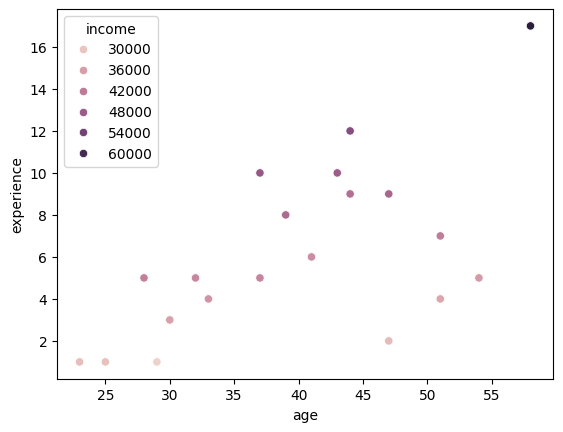

In [41]:
sns.scatterplot(x="age", y="experience", data=dataset, hue="income")
plt.show()

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns=x.columns)
x

,age,experience
0,-1.498903,-1.293548
1,-0.987332,-0.796030
2,0.752009,-1.044789
3,-0.782703,-0.298511
4,0.342752,0.945285
5,1.161266,0.199007
6,-1.191960,-0.298511
7,-0.680389,-0.547270
8,-0.271133,-0.298511
9,-0.066504,0.447767


In [44]:
from sklearn.model_selection import train_test_split

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

In [48]:
from sklearn.neighbors import KNeighborsRegressor

In [53]:
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [54]:
knn.score(x_train, y_train)*100

78.96638707209125

In [55]:
knn.score(x_test, y_test)*100

77.37621608056908

In [52]:
for i in range(1, 15):
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(x_train, y_train)
    print(i, knn.score(x_train, y_train), knn.score(x_test, y_test))

1 1.0 0.7847802116974187
2 0.9364877471431888 0.8844169531001999
3 0.8511493799037483 0.8076337642449479
4 0.7896638707209125 0.7737621608056908
5 0.7087723611247356 0.7438411681842672
6 0.6415506025706398 0.6124650823341117
7 0.5379255916997443 0.5454227770661717
8 0.5021815118045164 0.4329672804246154
9 0.409428121264522 0.4051456326767118
10 0.39261046175287573 0.3030302534839988
11 0.33855155609263876 0.36606564063760905
12 0.29186537719878225 0.22083519367744597
13 0.2512493088113328 0.1433702515429639
14 0.26678144815428895 0.12611675059410954


In [56]:
knn.predict([[1.083596, -0.990844]])

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([37667.5])